# Week 4: Vector Power-Up & Raster Integration

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

This week you will:
1. Master vector aggregation (dissolve & groupby)
2. Understand raster data as NumPy arrays with spatial metadata
3. Compute terrain slope from DEM
4. Extract raster values into vector shapes (zonal statistics)

**Packages needed:** `geopandas`, `rioxarray`, `rasterstats`, `numpy`, `matplotlib`

> If you haven't installed them yet, run:  
> `pip install rioxarray rasterstats geopandas folium mapclassify matplotlib`

## Cell [1] — Environment Setup

Import all necessary packages and load Week 3 township data.

In [ ]:

# Import
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rioxarray  # noqa: F401
import xarray as xr  # noqa: F401

import requests
import zipfile
from pathlib import Path
from urllib.parse import quote

# TGOS URL
TGOS_BASE = "https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/"
url = TGOS_BASE + quote("鄉(鎮、市、區)界線1140318.zip")

zip_path = Path("townships.zip")
extract_folder = Path("townships_data")

# 1. 下載 zip
r = requests.get(url)
r.raise_for_status()

with open(zip_path, "wb") as f:
    f.write(r.content)

# 2. 解壓縮
extract_folder.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_folder)

# 3. 找檔名包含 TOWN_MOI_1140318 的 shp
shp_files = list(extract_folder.rglob("*TOWN_MOI_1140318*.shp"))

if not shp_files:
    raise FileNotFoundError("找不到檔名包含 TOWN_MOI_1140318 的 .shp 檔")

shp_file = shp_files[0]
print("Using shapefile:", shp_file)

# 4. 讀取 shapefile
townships = gpd.read_file(shp_file)

# 5. 轉換到 EPSG:3826
townships = townships.to_crs(epsg=3826)

# 6. 輸出 shape、CRS、前五列
print("Shape:", townships.shape)
print("CRS:", townships.crs)
display(townships.head())

Using shapefile: townships_data\TOWN_MOI_1140318.shp
Shape: (368, 8)
CRS: EPSG:3826


,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
0,V02,10014020,臺東縣,成功鎮,Chenggong Township,V,10014,"POLYGON ((286994.568 2569686.978, 287066.318 2..."
1,T21,10013210,屏東縣,佳冬鄉,Jiadong Township,T,10013,"POLYGON ((203528.677 2484633.419, 203536.121 2..."
2,P13,10009130,雲林縣,麥寮鄉,Mailiao Township,P,10009,"POLYGON ((178880.906 2634847.772, 178880.637 2..."
3,V11,10014110,臺東縣,綠島鄉,Lüdao Township,V,10014,"MULTIPOLYGON (((300508.457 2508651.739, 300539..."
4,V16,10014160,臺東縣,蘭嶼鄉,Lanyu Township,V,10014,"MULTIPOLYGON (((313194.739 2427361.112, 313146..."


## Cell [2] — Dissolve & Groupby

**Dissolve**: Merge 368 townships → ~22 counties  
**Groupby**: Count shelters per county and sum capacity

In [ ]:

# 1. Dissolve townships by 'COUNTYNAME' → counties GeoDataFrame
counties = townships.dissolve(by="COUNTYNAME", as_index=False)

# 2. Print: how many counties? What geometry types?
print("Number of counties:", len(counties))
print("Geometry types:", counties.geom_type.unique())

# 3. Calculate area in km² for each county
# EPSG:3826 uses meters, so area is m²; divide by 1,000,000 to get km²
counties["area_km2"] = counties.geometry.area / 1_000_000

# 4. Show the top 5 largest counties
top5_largest = counties.sort_values("area_km2", ascending=False).head(5)

print("\nTop 5 largest counties (km²):")
display(top5_largest[["COUNTYNAME", "area_km2", "geometry"]])

Number of counties: 22
Geometry types: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str

Top 5 largest counties (km²):


,COUNTYNAME,area_km2,geometry
16,花蓮縣,4605.284306,"POLYGON ((288579.538 2575721.578, 288579.42 25..."
0,南投縣,4097.729914,"POLYGON ((230988.264 2610843.019, 230928.264 2..."
15,臺東縣,3582.210917,"MULTIPOLYGON (((244483.806 2484144.924, 244446..."
21,高雄市,2998.488305,"MULTIPOLYGON (((-478428.808 1154597.435, -4784..."
5,屏東縣,2805.036755,"MULTIPOLYGON (((186386.346 2472850.374, 186394..."


---

## 🔬 Lab 1: Vector Aggregation (20 minutes)

**Goal**: Practice dissolve & groupby before entering the raster world.

> **⚠️ 注意**：Lab 1 使用**合成資料**（synthetic data）練習 dissolve/groupby 操作。課後作業（ARIA v2.0）會使用**真實的避難收容所 CSV**，操作方式相同但資料來源不同。

### Step 1: Dissolve townships → counties

In [ ]:
# 1. Dissolve townships into counties
counties = townships.dissolve(by="COUNTYNAME", as_index=False)

# 2. 篩選花蓮縣
hualien = counties[counties["COUNTYNAME"] == "花蓮縣"]

# 3. 幾何型態
geom_type = hualien.geom_type.values[0]

# 4. 面積（km²）
area_km2 = hualien.geometry.area.values[0] / 1_000_000

# 5. 輸出結果
print("County: 花蓮縣")
print("Geometry type:", geom_type)
print("Area (km²):", area_km2)

County: 花蓮縣
Geometry type: Polygon
Area (km²): 4605.284306394598


### Step 2: Create synthetic shelter data for Hualien

In [13]:

# Filter Hualien County townships
hualien_towns = townships[townships["COUNTYNAME"] == "花蓮縣"].copy()

# Reproducibility
np.random.seed(42)

# Create synthetic shelters
records = []
shelter_counter = 1

for _, row in hualien_towns.iterrows():
    town_name = row["TOWNNAME"]
    centroid = row.geometry.centroid
    
    # Each town gets 2–8 shelters
    n_shelters = np.random.randint(2, 9)
    
    for _ in range(n_shelters):
        capacity = np.random.randint(50, 501)
        
        records.append({
            "shelter_id": f"S{shelter_counter:03d}",
            "TOWNNAME": town_name,
            "capacity": capacity,
            "geometry": centroid
        })
        
        shelter_counter += 1

# Create GeoDataFrame
shelters = gpd.GeoDataFrame(records, crs="EPSG:3826")

# Show result
print("Number of shelters:", len(shelters))
print("CRS:", shelters.crs)
display(shelters.head())

Number of shelters: 60
CRS: EPSG:3826


,shelter_id,TOWNNAME,capacity,geometry
0,S001,光復鄉,485,POINT (294406.293 2615944.762)
1,S002,光復鄉,398,POINT (294406.293 2615944.762)
2,S003,光復鄉,320,POINT (294406.293 2615944.762)
3,S004,光復鄉,156,POINT (294406.293 2615944.762)
4,S005,光復鄉,121,POINT (294406.293 2615944.762)


### Step 3: Groupby — Statistics per town

In [14]:

# Group shelters by TOWNNAME
summary = (
    shelters
    .groupby("TOWNNAME")
    .agg(
        shelter_count=("shelter_id", "count"),
        total_capacity=("capacity", "sum"),
        avg_capacity=("capacity", "mean")
    )
    .reset_index()
)

# Sort by total capacity descending
summary = summary.sort_values("total_capacity", ascending=False)

# Display all rows
display(summary)

,TOWNNAME,shelter_count,total_capacity,avg_capacity
1,卓溪鄉,8,2363,295.375000
9,花蓮市,8,1990,248.750000
0,光復鄉,8,1940,242.500000
10,萬榮鄉,5,1609,321.800000
4,富里鄉,6,1496,249.333333
6,玉里鎮,6,1341,223.500000
2,吉安鄉,3,1199,399.666667
3,壽豐鄉,3,1060,353.333333
12,鳳林鎮,3,946,315.333333
5,新城鄉,3,811,270.333333


### Step 4: Merge stats back to geometry & visualize

In [15]:
from pathlib import Path

# 1. Merge the groupby statistics back to the Hualien township geometry
# 如果你上一題的結果變數叫 summary，可直接用；若叫 town_summary 也可改成那個名稱
town_summary = summary.copy()

hualien_towns_stats = hualien_towns.merge(town_summary, on="TOWNNAME", how="left")

# 2. Create an interactive map with .explore() showing total_capacity by color
# .explore() 建議使用 EPSG:4326
hualien_towns_stats_4326 = hualien_towns_stats.to_crs(epsg=4326)

m = hualien_towns_stats_4326.explore(
    column="total_capacity",
    cmap="YlOrRd",
    tooltip=["TOWNNAME", "shelter_count", "total_capacity"],
    legend=True,
    tiles="OpenStreetMap"
)

# 3. Save the map as HTML
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

output_html = output_dir / "lab1_hualien_capacity.html"
m.save(str(output_html))

print("Saved interactive map to:", output_html)

Saved interactive map to: outputs\lab1_hualien_capacity.html


---

## Cell [3] — The Raster Glass Box: It's Just a Matrix

A raster (like a DEM) is a **NumPy array with a GPS**. Each pixel = one numeric value.

In [16]:
import numpy as np
import xarray as xr
import rioxarray  # noqa: F401
from rasterio.transform import from_bounds

# Grid size
width = 100
height = 80

# Bounds
xmin, xmax = 302000, 303600
ymin, ymax = 2638000, 2640000

# Normalized meshgrids (0~1)
x_norm = np.linspace(0, 1, width)
y_norm = np.linspace(0, 1, height)
X, Y = np.meshgrid(x_norm, y_norm)

# Valley DEM formula: low center, mountains on sides
dem_values = 50 + 800 * (2 * X - 1) ** 2 + 200 * Y + 30 * np.sin(8 * X) * np.cos(6 * Y)

# Coordinate arrays (pixel centers)
x_coords = np.linspace(xmin + (xmax - xmin) / width / 2,
                       xmax - (xmax - xmin) / width / 2,
                       width)
y_coords = np.linspace(ymax - (ymax - ymin) / height / 2,
                       ymin + (ymax - ymin) / height / 2,
                       height)

# Wrap as xarray DataArray
dem = xr.DataArray(
    dem_values,
    dims=("y", "x"),
    coords={"y": y_coords, "x": x_coords},
    name="dem"
)

# Set spatial metadata
dem = dem.rio.write_crs("EPSG:3826")
transform = from_bounds(xmin, ymin, xmax, ymax, width, height)
dem = dem.rio.write_transform(transform)

# Print info
print("Shape:", dem.shape)
print("CRS:", dem.rio.crs)
print("Resolution:", dem.rio.resolution())
print("Min elevation:", float(dem.min().values))
print("Max elevation:", float(dem.max().values))
print("\nTop-left 5x5 values:")
print(dem.values[:5, :5])

Shape: (80, 100)
CRS: EPSG:3826
Resolution: (16.0, -25.0)
Min elevation: 25.826058558849837
Max elevation: 1078.4985717378083

Top-left 5x5 values:
[[850.         820.4248699  791.48693004 763.17047923 735.46002188]
 [852.53164557 822.94953454 794.00465932 765.68136397 737.96419758]
 [855.06329114 825.46027759 796.49463627 768.15084676 740.41359191]
 [857.59493671 827.95721956 798.95710112 770.579286   742.8086791 ]
 [860.12658228 830.44056053 801.39245275 772.96727673 745.15024649]]


## Cell [4] — Affine Transform

How does `Matrix[row, col]` become real-world `(X, Y)` coordinates?

In [17]:
# Read the affine transform from DEM
transform = dem.rio.transform()

# Extract 6 affine parameters
a = transform.a   # pixel width
b = transform.b   # row rotation
c = transform.c   # top-left x
d = transform.d   # column rotation
e = transform.e   # pixel height (usually negative for north-up rasters)
f = transform.f   # top-left y

# Print the 6 parameters and explain what each means
print("Affine transform parameters:")
print(f"a = {a}  -> pixel width (x direction)")
print(f"b = {b}  -> row rotation term")
print(f"c = {c}  -> top-left x coordinate")
print(f"d = {d}  -> column rotation term")
print(f"e = {e}  -> pixel height (y direction, often negative)")
print(f"f = {f}  -> top-left y coordinate")

# Manually convert pixel [5, 10] to real-world coordinates
# row = 5, col = 10
row = 5
col = 10

real_x = a * col + b * row + c
real_y = d * col + e * row + f

# Elevation at that pixel
elevation = dem.values[row, col]

print("\nPixel location:")
print(f"row = {row}, col = {col}")

print("\nManual coordinate conversion:")
print(f"real_x = a*col + b*row + c = {real_x}")
print(f"real_y = d*col + e*row + f = {real_y}")

print("\nElevation at pixel [5, 10]:", elevation)

Affine transform parameters:
a = 16.0  -> pixel width (x direction)
b = 0.0  -> row rotation term
c = 302000.0  -> top-left x coordinate
d = 0.0  -> column rotation term
e = -25.0  -> pixel height (y direction, often negative)
f = 2640000.0  -> top-left y coordinate

Pixel location:
row = 5, col = 10

Manual coordinate conversion:
real_x = a*col + b*row + c = 302160.0
real_y = d*col + e*row + f = 2639875.0

Elevation at pixel [5, 10]: 592.2193631709488


## Cell [5] — DEM Visualization

Create a side-by-side plot: elevation + hillshade.

Saved to: outputs\cell5_dem.png


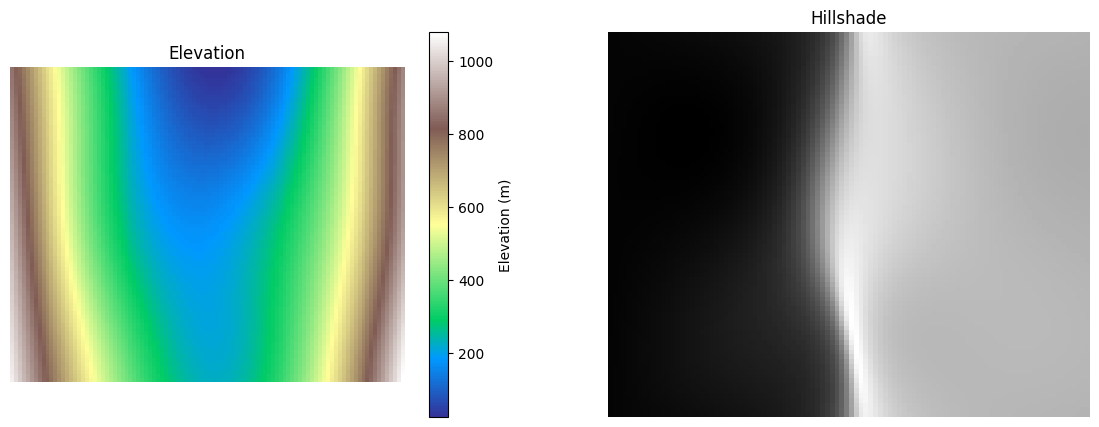

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from pathlib import Path

# Create output folder
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: DEM elevation ---
im = axes[0].imshow(dem.values, cmap="terrain", origin="upper")
axes[0].set_title("Elevation")
axes[0].set_axis_off()

cbar = plt.colorbar(im, ax=axes[0])
cbar.set_label("Elevation (m)")

# --- Right: Hillshade ---
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem.values, vert_exag=1, dx=1, dy=1)

axes[1].imshow(hillshade, cmap="gray", origin="upper")
axes[1].set_title("Hillshade")
axes[1].set_axis_off()

# Save figure
output_path = output_dir / "cell5_dem.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")

print("Saved to:", output_path)

plt.show()

---

## 🔬 Lab 2: Raster Exploration on Colab (15 minutes)

### ⚡ 請選擇你的環境：

| | **Option A: Google Colab（建議）** | **Option B: 本機 fallback** |
|---|---|---|
| 適用情境 | 網路正常、Drive mount 成功 | Colab 有問題或無法連線 |
| DEM 來源 | `dem_20m_hualien.tif`（Pre-lab 已下載到 Drive） | 使用 Cell [3] 的合成 DEM (`dem_synth`) |
| 後續 Step 2-4 | 用 `dem` 變數 | 用 `dem_synth` 變數（已在前面建立） |

> **Fallback 快速切換**：如果 Colab 不通，跳過 Step 1，直接到 Step 2，把 `dem` 改成 `dem_synth` 即可繼續。
> 
> **Note**: Steps 5-6 (zonal stats & risk classification) are included for reference — they will be completed in the homework.

### Step 1: Colab Setup
由於作業區無法繳交兩個網址，因此Lab2作業請參考以下連結：
https://colab.research.google.com/drive/1m3a6Jk2HkAa55nwgZlb4-YG2D0RoeoWg?usp=sharing#scrollTo=XShOpOZ_G9xy

In [ ]:
# Lab 2 Step 1: Run in Colab!
# 1. Install packages: !pip install rioxarray rasterstats geopandas -q
# 2. Mount Google Drive
# 3. Import all packages

# AI Prompt suggestion:
# "Set up my Colab environment:
#  1. pip install rioxarray rasterstats geopandas
#  2. Mount Google Drive with drive.mount('/content/drive')
#  3. Import rioxarray, geopandas, numpy, matplotlib.pyplot, rasterstats"


---

## Week 4 Reflection

Answer in the markdown cell below:

### My Reflection (fill in)

1. **Why is "distance to river" alone insufficient for flood risk assessment?**
   
   與河流之距離只是其中一個因素，地勢高低、坡度、排水能力也會影響淹水風險。像低窪地區即使離河遠，也可能因為積水而發生淹水。

2. **What causes zonal_stats to return NaN, and how do you fix it?**
   
   通常是因為緩衝區沒有覆蓋到 raster，或 CRS 不一致導致位置錯誤。透過檢查座標系統是否一致，並確認幾何範圍有重疊。

3. **When combining vector and raster, should you reproject the vector or the raster? Why?**
   
   通常會把 vector 重投影到 raster 的 CRS，比較不會影響原始影像資料。因為重投影 raster 可能會改變像素值或解析度。

4. **What was the most surprising thing you learned about raster data today?**
   
   原來 raster 的每個像素都有實際地理位置，可以用 affine transform 算出座標。還有像 slope 這種分析其實是用數值方法算出來的，跟影像有直接關係。